# Building the wiring diagram

In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append('../../')

In [10]:

import glob
import pickle
from pathlib import Path

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, cross_validate, StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin
from tools.viz.rc_style import rc_context_talk


from tqdm import tqdm
import pickle

from joblib import Parallel, delayed

import numpy as np

In [21]:
data_dir='/data/bnd-data/raw/'

SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_17_14_00",
    "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_24_15_00",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]


for sess in SESSIONS:
    td, _ = dsp.load_and_process_session(sess, std=0.03)
    perturb_td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)
    perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['all_spikes', 'CP_spikes', 'MOp_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (15, 48000)
Resulting CP_spikes ephys data shape is (NxT): (267, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (190, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (126, 48000)
Skipped 8 trials
Otsu immobility threshold: 6.6387
Dropped 70 of 497 rows (14.08%).


/tmp/ipykernel_1321534/1196816324.py:24: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  perturb_td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)


In [23]:
pc_dict = {
    "MOp": 30,
    "SSp": 25,
    "CP": 30,
    "VAL": 40,
}
td_potent_null = perturb_td_shuff.copy()
for area_a in Params.areas:
    for area_b in Params.areas:
        if area_b == area_a:
            continue
        td_potent_null = subspaces.compute_potent_null_td(
            td_=td_potent_null,
            signal_x=f'{area_a}_rates_pca',
            signal_y=f'{area_b}_rates_pca',
            origin_rank=pc_dict[area_a],
            target_rank=pc_dict[area_b],
            n_iter=2,
            window=(0, 200),
            thresh=0.05
        )

Computing MOp_rates_pca -> SSp_rates_pca potent and null subspaces
Prediction R2 = 0.2918. Optimal rank: 8
Using 2 iterations...
	Iter: 1. Prediction R2 = 0.0856
	Iter: 2. Prediction R2 = 0.0160
Iteration number: 2. R2 below 0.05, breaking
	Final Prediction R2 = 0.0160
Diagnostics:
	Total MOp_rates_pca var:         12480.16
	Fraction Potent (dim: 8) var:    0.305
	Fraction Null (dim: 14) var:      0.189
	Fraction Null init var:          0.320
	Fraction MOp_rates_pca var:      0.625
Computing MOp_rates_pca -> CP_rates_pca potent and null subspaces
Prediction R2 = 0.2841. Optimal rank: 10
Using 2 iterations...
	Iter: 1. Prediction R2 = 0.0583
	Iter: 2. Prediction R2 = 0.0043
Iteration number: 2. R2 below 0.05, breaking
	Final Prediction R2 = 0.0043
Diagnostics:
	Total MOp_rates_pca var:         12480.16
	Fraction Potent (dim: 10) var:    0.214
	Fraction Null (dim: 10) var:      0.173
	Fraction Null init var:          0.411
	Fraction MOp_rates_pca var:      0.625
Computing MOp_rates_pca -

In [17]:
mempool = cp.get_default_memory_pool()
pinned_mempool = cp.get_default_pinned_memory_pool()


mempool.free_all_blocks()
pinned_mempool.free_all_blocks()

In [24]:
td_potent_null_vm = subspaces.match_null_variance_to_potent(td_potent_null, Params.areas)


MOp -> SSp: null var (2357.7) <= potent var (3807.1), skipping
MOp -> CP: null var (2159.0) <= potent var (2672.4), skipping
MOp -> VAL: null var 3737.6 -> 2253.2 (potent: 2153.9) | dims 14 -> 6
SSp -> MOp: null var (2589.0) <= potent var (2822.3), skipping
SSp -> CP: null var 3069.8 -> 2350.7 (potent: 2341.5) | dims 17 -> 12
SSp -> VAL: null var 3917.1 -> 1482.0 (potent: 1494.2) | dims 19 -> 5
CP -> MOp: null var (2384.7) <= potent var (4373.9), skipping
CP -> SSp: null var (3491.2) <= potent var (3756.4), skipping
CP -> VAL: null var (3221.9) <= potent var (3981.5), skipping
VAL -> MOp: null var 10678.3 -> 8719.1 (potent: 8682.1) | dims 28 -> 20
VAL -> SSp: null var (6563.0) <= potent var (8853.5), skipping
VAL -> CP: null var (5185.0) <= potent var (10462.5), skipping


  drop_trials_sem_crosses_zero: by SEM: 292  |  by value: 423  |  kept: 291/424 (68.6%)
MOp->SSp  full=0.246  potent=0.229  null=0.011
MOp->CP  full=0.246  potent=0.219  null=0.004
MOp->VAL  full=0.246  potent=0.159  null=0.032
SSp->MOp  full=0.282  potent=0.269  null=0.060
SSp->CP  full=0.282  potent=0.265  null=0.068
SSp->VAL  full=0.282  potent=0.146  null=0.183
CP->MOp  full=0.151  potent=0.138  null=0.002
CP->SSp  full=0.151  potent=0.137  null=0.006
CP->VAL  full=0.151  potent=0.104  null=0.025
VAL->MOp  full=0.146  potent=0.129  null=0.049
VAL->SSp  full=0.146  potent=0.120  null=0.014
VAL->CP  full=0.146  potent=0.114  null=0.017


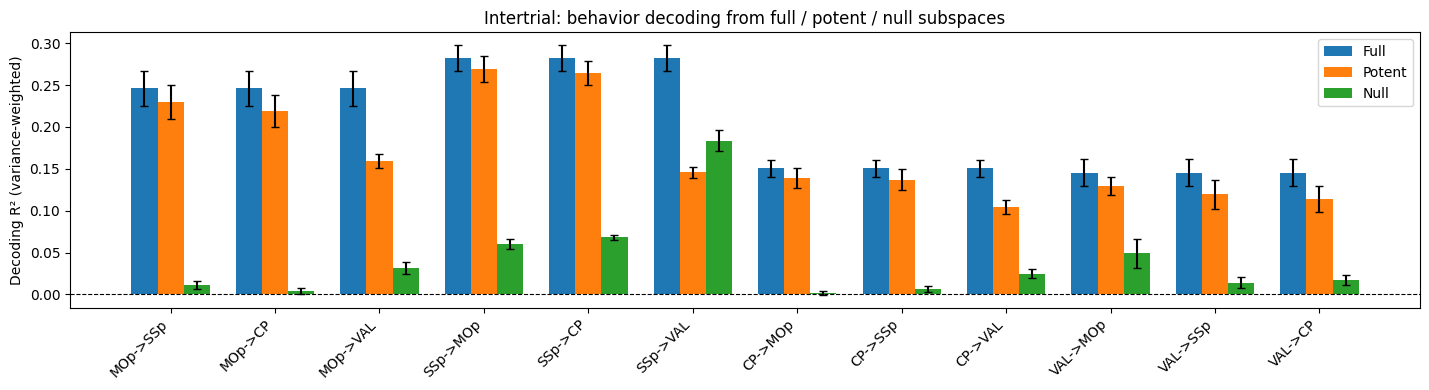

In [25]:
td_drop = dsp.drop_trials_sem_crosses_zero(td_potent_null_vm, std=False)

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
WINDOW = (0, 200)

def decode_r2(td, signal, n_pcs, bhv_n_cols, cv):
    X = np.stack(td[signal].values)[:, WINDOW[0]:WINDOW[1], :]
    n_trials, n_time, n_dims = X.shape
    X_flat = X.reshape(n_trials * n_time, n_dims)
    if n_pcs is not None:
        X_flat = X_flat[:, :n_pcs]
    y = np.stack(td.bhv.values)[:, WINDOW[0]:WINDOW[1], :]
    y = y.reshape(-1, bhv_n_cols)
    r2s = cross_val_score(Ridge(0.01), X_flat, y, cv=cv, scoring=vw_r2_scorer)
    return r2s.mean(), r2s.std()

bhv_n_cols = len(Params.oscillating_key_points) * 3
cv = KFold(5, shuffle=False)
td = td_potent_null

results = {}   # (area_x, area_y) -> {full, potent, null}

for area_x in Params.areas:
    for area_y in Params.areas:
        if area_x == area_y:
            continue
        potent_col = f"{area_x}_rates_pca_potent_{area_y}_rates_pca"
        null_col   = f"{area_x}_rates_pca_null_{area_y}_rates_pca"
        if potent_col not in td.columns:
            continue

        r2_full   = decode_r2(td, f"{area_x}_rates_pca", pc_dict[area_x], bhv_n_cols, cv)
        r2_potent = decode_r2(td, potent_col, None, bhv_n_cols, cv)
        r2_null   = decode_r2(td, null_col,   None, bhv_n_cols, cv)

        results[(area_x, area_y)] = dict(full=r2_full, potent=r2_potent, null=r2_null)
        print(f"{area_x}->{area_y}  full={r2_full[0]:.3f}  potent={r2_potent[0]:.3f}  null={r2_null[0]:.3f}")

# --- Plot ---
pairs   = list(results.keys())
labels  = [f"{a}->{b}" for a, b in pairs]
x       = np.arange(len(pairs))
width   = 0.25

full_m   = [results[p]["full"][0]   for p in pairs]
potent_m = [results[p]["potent"][0] for p in pairs]
null_m   = [results[p]["null"][0]   for p in pairs]
full_s   = [results[p]["full"][1]   for p in pairs]
potent_s = [results[p]["potent"][1] for p in pairs]
null_s   = [results[p]["null"][1]   for p in pairs]

fig, ax = plt.subplots(figsize=(max(6, len(pairs) * 1.2), 4))

ax.bar(x - width, full_m,   width, yerr=full_s,   label="Full",   capsize=3)
ax.bar(x,         potent_m, width, yerr=potent_s, label="Potent", capsize=3)
ax.bar(x + width, null_m,   width, yerr=null_s,   label="Null",   capsize=3)

ax.axhline(0, color="k", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Decoding R² (variance-weighted)")
ax.set_title("Intertrial: behavior decoding from full / potent / null subspaces")
ax.legend()
fig.tight_layout()
plt.show()

# print("\\nSummary:")
# for (ax_, ay), v in results.items():
#     print(f"{ax_}->{ay}: full={v[\'full\'][0]:.3f}±{v[\'full\'][1]:.3f}  potent={v[\'potent\'][0]:.3f}±{v[\'potent\'][1]:.3f}  null={v[\'null\'][0]:.3f}±{v[\'null\'][1]:.3f}\")
